In [1]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
 pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.9 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.5 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.7 MB/s  0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('../data/creditcard.csv')

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load saved model
model = joblib.load('../notebooks/models/fraud_model.pkl')
print("Model loaded!")

Model loaded!


In [3]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on test set
# Using a sample of 1000 rows — full dataset is slow
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated!")

SHAP values calculated!


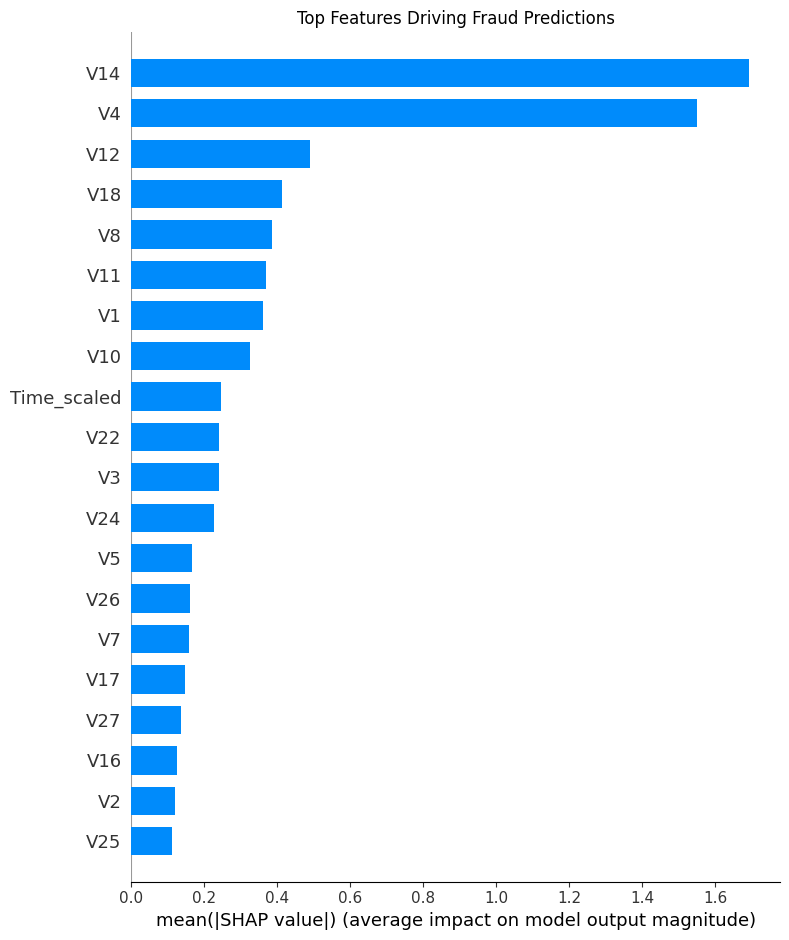

In [10]:
plt.figure()
shap.summary_plot(
    shap_values,      # fraud class
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("Top Features Driving Fraud Predictions")
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(shap_values[1].shape)
print(shap_values.shape)

<class 'numpy.ndarray'>
1000
(30,)
(30,)
(1000, 30)


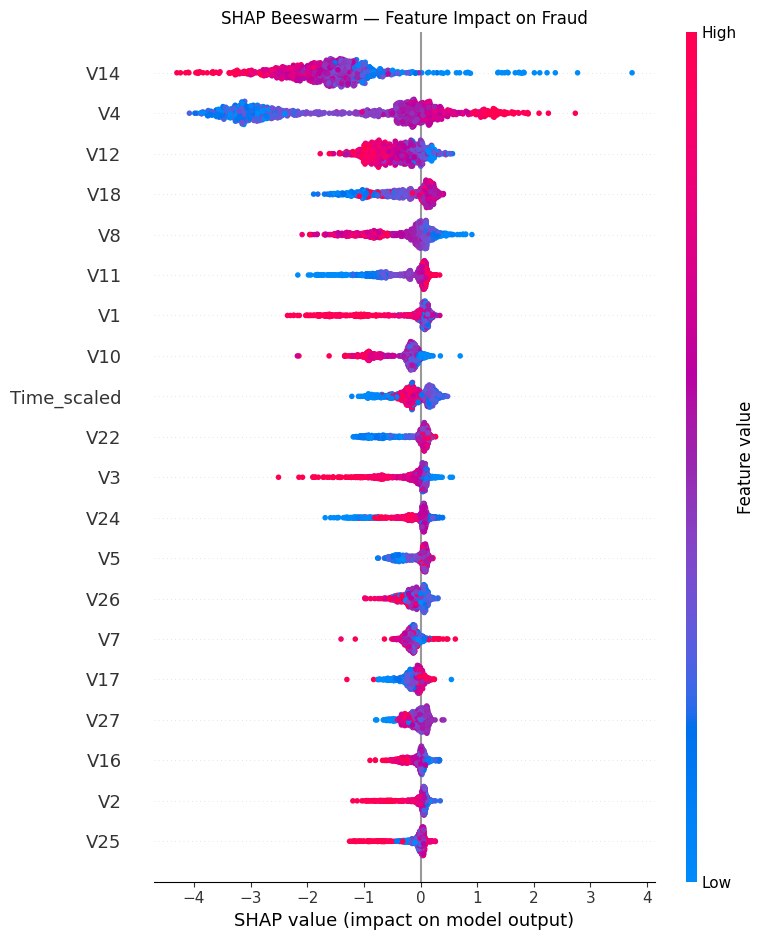

In [11]:
shap.summary_plot(
    shap_values,         
    X_test_sample,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Fraud")
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

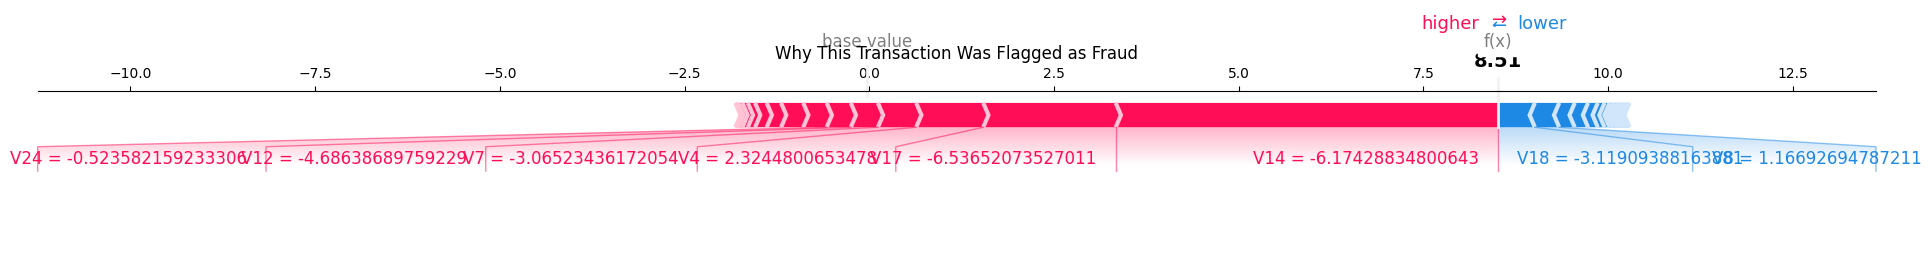

In [12]:
fraud_idx = y_test[y_test == 1].index[0]
fraud_transaction = X_test.loc[[fraud_idx]]

shap_single = explainer.shap_values(fraud_transaction)

shap.force_plot(
    explainer.expected_value,   
    shap_single[0],             
    fraud_transaction.iloc[0],
    matplotlib=True,
    show=False
)
plt.title("Why This Transaction Was Flagged as Fraud")
plt.tight_layout()
plt.savefig('../reports/shap_single.png', dpi=150, bbox_inches='tight')
plt.show()